## SETUP

In [1]:
from pathlib import Path

import pandas as pd
import tensorflow as tf
import yaml
from tensorflow.image import grayscale_to_rgb
from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras.metrics import AUC, BinaryAccuracy, Precision, Recall
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
)

from breast_cancer.data import optimize_dataset, prepare_dataset
from breast_cancer.models import build_ensemble_shared_backbone
from breast_cancer.utils import get_save_path
from breast_cancer.utils.plots import plot_history

2025-09-22 01:52:19.634312: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-09-22 01:52:19.703915: I tensorflow/core/util/util.cc:169] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-09-22 01:52:19.721536: E tensorflow/stream_executor/cuda/cuda_blas.cc:2981] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-09-22 01:52:20.031757: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvi

In [2]:
# Check installed tensorflow version
print(f"Tensorflow version: {tf.__version__}")

# Check GPU availability
print(f"GPU List: {tf.config.list_physical_devices('GPU')}")

Tensorflow version: 2.10.1
GPU List: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
# Import general configurations
with open("../configs/default.yml") as f:
    default_cfg = yaml.load(f, Loader=yaml.FullLoader)

# Import training configurations
with open("../configs/training.yml") as f:
    training_cfg = yaml.load(f, Loader=yaml.FullLoader)

# Import model configurations
with open("../configs/model_ensemble_shared.yml") as f:
    model_cfg = yaml.load(f, Loader=yaml.FullLoader)

In [4]:
dir_data_split = Path(default_cfg["dirs"]["data_split"])
dir_data_split.mkdir(parents=True, exist_ok=True)

dir_model_logs = Path(default_cfg["dirs"]["model_logs"])
dir_model_logs.mkdir(parents=True, exist_ok=True)

dir_model_initial = Path(default_cfg["dirs"]["model_initial"])
dir_model_initial.mkdir(parents=True, exist_ok=True)

dir_model_final = Path(default_cfg["dirs"]["model_final"])
dir_model_final.mkdir(parents=True, exist_ok=True)

In [5]:
def get_dataset(image_paths, image_labels, image_resize, dataset_cfg):
    if isinstance(image_resize, int):
        image_resize = (image_resize, image_resize)
    dataset = prepare_dataset(image_paths, image_labels, image_resize)
    dataset = optimize_dataset(dataset, **dataset_cfg)
    return dataset

def append_histories(*histories):
    import re
    merged = {}
    for h in histories:
        for k, v in h.history.items():
            new_k = re.sub(r'_\d+$', '', k)
            merged.setdefault(new_k, []).extend(v)
    return merged

In [6]:
# Set random seeds
tf.random.set_seed(default_cfg["random_seed"])

In [7]:
EPOCHS = 80

## MODEL STARTING POINT

In [8]:
from tensorflow.keras.applications import ResNet50V2

# Build backbone from pretrained model
new_cfg = model_cfg["base_model_args"].copy()
backbone = ResNet50V2(**model_cfg["base_model_args"])

# Build model from spec
model_cfg["model_args"]["name"] = f"ensemble_{backbone.name}"
model = build_ensemble_shared_backbone(backbone, model_cfg["model_args"])
model.summary()

# Save initial weights for multiple training configurations
save_path = get_save_path(default_cfg["dirs"]["model_initial"], f"{model.name}_{backbone.name}", "")
model.save_weights(save_path)
print(f"Model initial weights are saved at {save_path}")

2025-09-22 01:52:24.543963: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-09-22 01:52:24.642453: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1616] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 22151 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4090, pci bus id: 0000:06:00.0, compute capability: 8.9


Model: "ensemble_resnet50v2"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_2 (InputLayer)           [(None, 256, 256, 3  0           []                               
                                )]                                                                
                                                                                                  
 resnet50v2 (Functional)        (None, 8, 8, 2048)   23564800    ['input_2[0][0]']                
                                                                                                  
 transition_layer (GlobalAverag  (None, 2048)        0           ['resnet50v2[0][0]']             
 ePooling2D)                                                                                      
                                                                                

## MODEL EXPLORATION

#### Split by image ID

In [9]:
df_train_image_random = pd.read_csv(dir_data_split / "train_image_random_aug.csv") # get the augmented version
df_val_image_random = pd.read_csv(dir_data_split / "val_image_random.csv")

df_train_image_random.head(3)

,Unnamed: 0,raw,processed,imageID,patientID,label,augmented,augmentID
0,0,../data/images/raw/benign/Calc-Training_P_0000...,../data/images/processed/Calc-Training_P_00007...,Calc-Training_P_00007_LEFT_CC_1,P_00007,benign,../data/images/augmented/Calc-Training_P_00007...,Calc-Training_P_00007_LEFT_CC_1-augmented-9
1,1,../data/images/raw/benign/Calc-Training_P_0000...,../data/images/processed/Calc-Training_P_00007...,Calc-Training_P_00007_LEFT_CC_1,P_00007,benign,../data/images/augmented/Calc-Training_P_00007...,Calc-Training_P_00007_LEFT_CC_1-augmented-8
2,2,../data/images/raw/benign/Calc-Training_P_0000...,../data/images/processed/Calc-Training_P_00007...,Calc-Training_P_00007_LEFT_CC_1,P_00007,benign,../data/images/augmented/Calc-Training_P_00007...,Calc-Training_P_00007_LEFT_CC_1-augmented-7


In [ ]:
ds_train_image_random = get_dataset(
    df_train_image_random["augmented"].values,
    df_train_image_random["label"].values,
    image_resize=default_cfg["image_resize"],
    dataset_cfg=training_cfg["low_memory_dataset"]["train"],
).map(lambda x, y: (grayscale_to_rgb(x), y)) # convert to 3-channel images

ds_val_image_random = get_dataset(
    df_val_image_random["processed"].values,
    df_val_image_random["label"].values,
    image_resize=default_cfg["image_resize"],
    dataset_cfg=training_cfg["low_memory_dataset"]["test"]
).map(lambda x, y: (grayscale_to_rgb(x), y)) # convert to 3-channel images

In [11]:
# Load the model and freeze backbone
model.load_weights(save_path)
backbone = model.get_layer("resnet50v2")
backbone.trainable = False

# Compile model with optimizer, loss, and metrics
optimizer = Adam(learning_rate=training_cfg["initial_training"]["lr"])
loss = BinaryCrossentropy()
metrics = [AUC(), BinaryAccuracy(), Precision(), Recall()]

model.compile(optimizer=optimizer, loss=loss, metrics=metrics)

# Setup callbacks
early_stop = EarlyStopping(monitor="val_loss", **training_cfg["initial_training"]["early_stopping"])
lr_reducer = ReduceLROnPlateau(monitor="val_loss", **training_cfg["initial_training"]["reduce_on_plateau"])

In [12]:
# Train head only
history_image1 = model.fit(
    ds_train_image_random,
    validation_data=ds_val_image_random,
    callbacks=[early_stop, lr_reducer],
    epochs=EPOCHS,
)

Epoch 1/80


2025-09-21 15:57:16.712928: I tensorflow/stream_executor/cuda/cuda_dnn.cc:384] Loaded cuDNN version 8905


   6/1289 [..............................] - ETA: 14s - loss: 0.7959 - auc: 0.0000e+00 - binary_accuracy: 0.4896 - precision: 0.0000e+00 - recall: 0.0000e+00    

2025-09-21 15:57:17.261611: I tensorflow/core/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2025-09-21 15:57:17.279706: I tensorflow/core/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2025-09-21 15:57:17.279753: W tensorflow/stream_executor/gpu/asm_compiler.cc:80] Couldn't get ptxas version string: INTERNAL: Couldn't invoke ptxas --version
2025-09-21 15:57:17.298398: I tensorflow/core/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2025-09-21 15:57:17.298585: W tensorflow/stream_executor/gpu/redzone_allocator.cc:314] INTERNAL: Failed to launch ptxas
Relying on driver to perform ptx compilation. 
Modify $PATH to customize ptxas location.
This message will be only logged once.
2025-09-21 15:57:17.318730: I tensorflow/stream_executor/cuda/cuda_blas.cc:1614] TensorFloat-32 will be used for the matrix multiplication. This will only be logged onc

1289/1289 [==============================] - 24s 13ms/step - loss: 0.7345 - auc: 0.6207 - binary_accuracy: 0.6102 - precision: 0.5299 - recall: 0.4865 - val_loss: 0.6841 - val_auc: 0.6987 - val_binary_accuracy: 0.6457 - val_precision: 0.5954 - val_recall: 0.4364 - lr: 1.0000e-04
Epoch 2/80
1289/1289 [==============================] - 14s 10ms/step - loss: 0.7144 - auc: 0.6415 - binary_accuracy: 0.6142 - precision: 0.5371 - recall: 0.4676 - val_loss: 0.6838 - val_auc: 0.7145 - val_binary_accuracy: 0.6283 - val_precision: 0.7347 - val_recall: 0.1525 - lr: 1.0000e-04
Epoch 3/80
1289/1289 [==============================] - 14s 11ms/step - loss: 0.6962 - auc: 0.6698 - binary_accuracy: 0.6437 - precision: 0.5837 - recall: 0.4747 - val_loss: 0.6812 - val_auc: 0.6954 - val_binary_accuracy: 0.6283 - val_precision: 0.7347 - val_recall: 0.1525 - lr: 1.0000e-04
Epoch 4/80
1289/1289 [==============================] - 13s 10ms/step - loss: 0.6840 - auc: 0.6867 - binary_accuracy: 0.6563 - precision: 

In [13]:
# Unfreeze parts of the backbone for fine tuning
backbone_layers = backbone.layers
start_trainable = -int(0.2*len(backbone_layers))

for l in backbone_layers[start_trainable:]:
    l.trainable = True

# Set new learning rate
tf.keras.backend.set_value(model.optimizer.lr, 1e-5)

# Fine tune head and last 20% backbone layers
history_image2 = model.fit(
    ds_train_image_random,
    validation_data = ds_val_image_random,
    callbacks=[early_stop, lr_reducer],
    epochs=EPOCHS,
)

Epoch 1/80
 932/1289 [====================>.........] - ETA: 3s - loss: 0.5107 - auc: 0.8184 - binary_accuracy: 0.7959 - precision: 0.6162 - recall: 0.5638

1289/1289 [==============================] - 14s 11ms/step - loss: 0.5335 - auc: 0.8421 - binary_accuracy: 0.7678 - precision: 0.7666 - recall: 0.6283 - val_loss: 0.6551 - val_auc: 0.7306 - val_binary_accuracy: 0.6894 - val_precision: 0.7636 - val_recall: 0.3559 - lr: 1.0000e-05
Epoch 2/80
1289/1289 [==============================] - 13s 10ms/step - loss: 0.5278 - auc: 0.8476 - binary_accuracy: 0.7706 - precision: 0.7701 - recall: 0.6327 - val_loss: 0.6561 - val_auc: 0.7299 - val_binary_accuracy: 0.6911 - val_precision: 0.7360 - val_recall: 0.3898 - lr: 1.0000e-05
Epoch 3/80
1289/1289 [==============================] - 14s 11ms/step - loss: 0.5267 - auc: 0.8490 - binary_accuracy: 0.7737 - precision: 0.7676 - recall: 0.6474 - val_loss: 0.6560 - val_auc: 0.7343 - val_binary_accuracy: 0.6928 - val_precision: 0.7381 - val_recall: 0.3941 - lr: 1.0000e-05
Epoch 4/80
1285/1289 [============================>.] - ETA: 0s - loss: 0.5270 - auc: 0.8486 - binary_accuracy: 0.7780 - precision: 0.7834

In [14]:
# Unfreeze all layers for fine tuning
model.trainable = True

# Fine tune the model
history_image3 = model.fit(
    ds_train_image_random,
    validation_data = ds_val_image_random,
    callbacks=[early_stop, lr_reducer],
    epochs=EPOCHS,
)

Epoch 1/80
1289/1289 [==============================] - 14s 11ms/step - loss: 0.5201 - auc: 0.8582 - binary_accuracy: 0.7821 - precision: 0.7802 - recall: 0.6568 - val_loss: 0.6611 - val_auc: 0.7399 - val_binary_accuracy: 0.6876 - val_precision: 0.7280 - val_recall: 0.3856 - lr: 3.2768e-06
Epoch 2/80
1188/1289 [==========================>...] - ETA: 1s - loss: 0.5193 - auc: 0.8505 - binary_accuracy: 0.7796 - precision: 0.7448 - recall: 0.6370

1289/1289 [==============================] - 14s 11ms/step - loss: 0.5244 - auc: 0.8525 - binary_accuracy: 0.7741 - precision: 0.7698 - recall: 0.6454 - val_loss: 0.6595 - val_auc: 0.7383 - val_binary_accuracy: 0.6911 - val_precision: 0.7438 - val_recall: 0.3814 - lr: 3.2768e-06
Epoch 3/80
1289/1289 [==============================] - 14s 11ms/step - loss: 0.5236 - auc: 0.8542 - binary_accuracy: 0.7757 - precision: 0.7714 - recall: 0.6483 - val_loss: 0.6613 - val_auc: 0.7389 - val_binary_accuracy: 0.6876 - val_precision: 0.7355 - val_recall: 0.3771 - lr: 3.2768e-06
Epoch 4/80
1289/1289 [==============================] - 14s 11ms/step - loss: 0.5235 - auc: 0.8536 - binary_accuracy: 0.7755 - precision: 0.7702 - recall: 0.6495 - val_loss: 0.6594 - val_auc: 0.7394 - val_binary_accuracy: 0.6928 - val_precision: 0.7459 - val_recall: 0.3856 - lr: 3.2768e-06
Epoch 5/80
1285/1289 [============================>.] - ETA: 0s - loss: 0.5180 - auc: 0.8594 - binary_accuracy: 0.7836 - precision: 0.7836

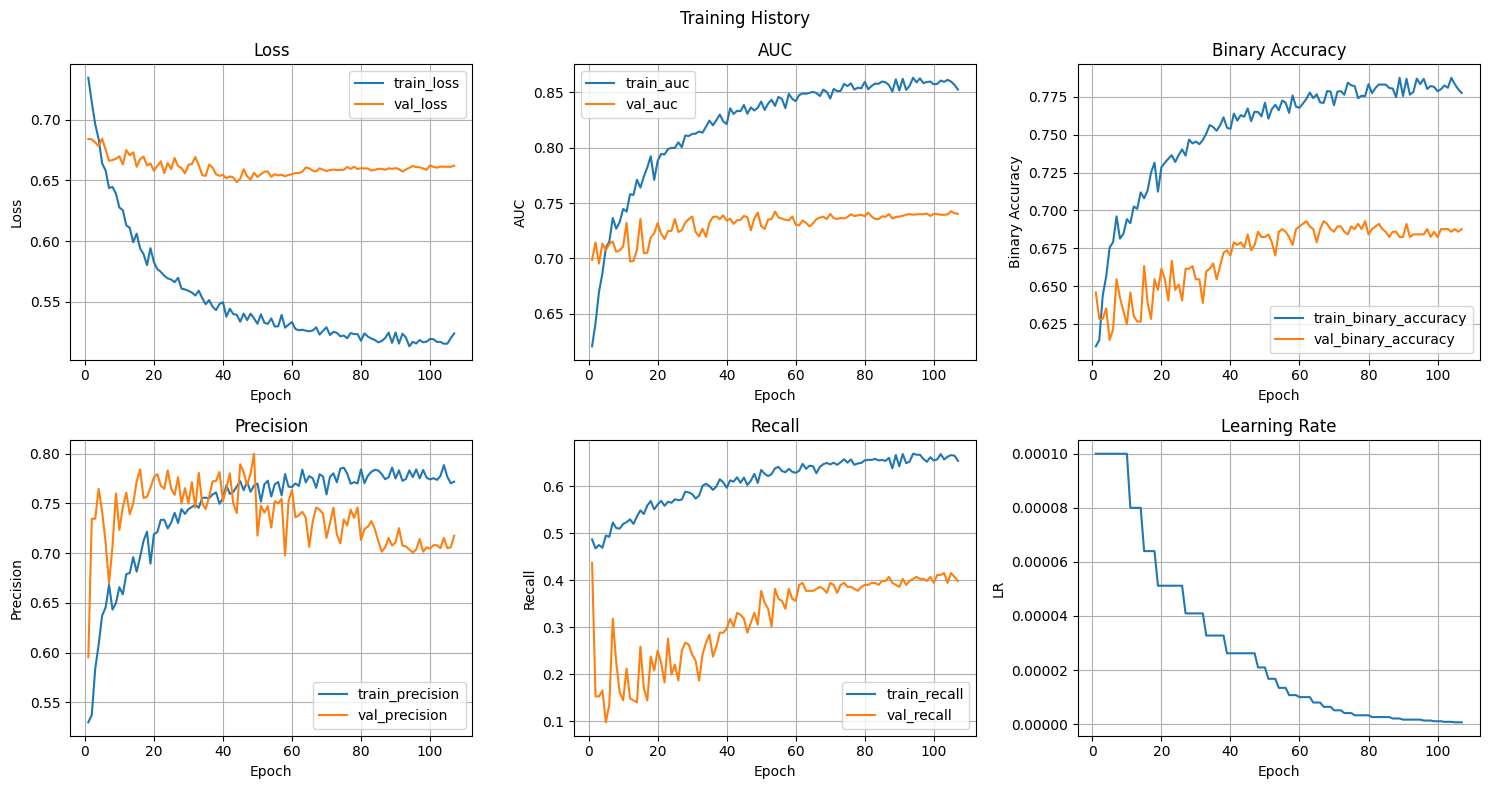

In [15]:
def append_histories(*histories):
    import re
    merged = {}
    for h in histories:
        for k, v in h.history.items():
            new_k = re.sub(r'_\d+$', '', k)
            merged.setdefault(new_k, []).extend(v)
    return merged

all_histories = append_histories(history_image1, history_image2, history_image3)

plot_history(all_histories)

In [16]:
logger_path = str(dir_model_logs/model.name/f"initial_{model.name}_{backbone.name}_image_random.csv")
Path(logger_path).parent.mkdir(exist_ok=True)

pd.DataFrame(all_histories).to_csv(logger_path)

f"Saved at {logger_path}"

'Saved at ../models/logs/ensemble_resnet50v2/initial_ensemble_resnet50v2_resnet50v2_image_random.csv'

#### Split by Patient ID

In [32]:
df_train_patient_random = pd.read_csv(dir_data_split / "train_patient_random_aug.csv") # get the augmented version
df_val_patient_random = pd.read_csv(dir_data_split / "val_patient_random.csv")

df_train_patient_random.head(3)

,Unnamed: 0,raw,processed,imageID,patientID,label,augmented,augmentID
0,0,../data/images/raw/benign/Calc-Test_P_00038_LE...,../data/images/processed/Calc-Test_P_00038_LEF...,Calc-Test_P_00038_LEFT_CC_1,P_00038,benign,../data/images/augmented/Calc-Test_P_00038_LEF...,Calc-Test_P_00038_LEFT_CC_1-augmented-9
1,1,../data/images/raw/benign/Calc-Test_P_00038_LE...,../data/images/processed/Calc-Test_P_00038_LEF...,Calc-Test_P_00038_LEFT_CC_1,P_00038,benign,../data/images/augmented/Calc-Test_P_00038_LEF...,Calc-Test_P_00038_LEFT_CC_1-augmented-8
2,2,../data/images/raw/benign/Calc-Test_P_00038_LE...,../data/images/processed/Calc-Test_P_00038_LEF...,Calc-Test_P_00038_LEFT_CC_1,P_00038,benign,../data/images/augmented/Calc-Test_P_00038_LEF...,Calc-Test_P_00038_LEFT_CC_1-augmented-7


In [33]:
ds_train_patient_random = get_dataset(
    df_train_patient_random["augmented"].values,
    df_train_patient_random["label"].values,
    image_resize=default_cfg["image_resize"],
    dataset_cfg=training_cfg["low_memory_dataset"]["train"],
).map(lambda x, y: (grayscale_to_rgb(x), y)) # convert to 3-channel images

ds_val_patient_random = get_dataset(
    df_val_patient_random["processed"].values,
    df_val_patient_random["label"].values,
    image_resize=default_cfg["image_resize"],
    dataset_cfg=training_cfg["low_memory_dataset"]["test"],
).map(lambda x, y: (grayscale_to_rgb(x), y)) # convert to 3-channel images

In [34]:
# Load the model and freeze backbone
model.load_weights(save_path)
backbone = model.get_layer("resnet50v2")
backbone.trainable = False

# Compile model with optimizer, loss, and metrics
optimizer = Adam(learning_rate=training_cfg["initial_training"]["lr"])
loss = BinaryCrossentropy()
metrics = [AUC(), BinaryAccuracy(), Precision(), Recall()]

model.compile(optimizer=optimizer, loss=loss, metrics=metrics)

# Setup callbacks
early_stop = EarlyStopping(monitor="val_loss", **training_cfg["initial_training"]["early_stopping"])
lr_reducer = ReduceLROnPlateau(monitor="val_loss", **training_cfg["initial_training"]["reduce_on_plateau"])

In [35]:
# Train head only
history_patient1 = model.fit(
    ds_train_patient_random,
    validation_data=ds_val_patient_random,
    callbacks=[early_stop, lr_reducer],
    epochs=EPOCHS,
)

Epoch 1/80


1264/1264 [==============================] - 23s 13ms/step - loss: 0.7435 - auc_1: 0.5953 - binary_accuracy: 0.5968 - precision_1: 0.5014 - recall_1: 0.4613 - val_loss: 0.6687 - val_auc_1: 0.7150 - val_binary_accuracy: 0.6530 - val_precision_1: 0.5537 - val_recall_1: 0.6321 - lr: 1.0000e-04
Epoch 2/80
1264/1264 [==============================] - 14s 11ms/step - loss: 0.7266 - auc_1: 0.6162 - binary_accuracy: 0.6080 - precision_1: 0.5176 - recall_1: 0.4482 - val_loss: 0.6650 - val_auc_1: 0.7103 - val_binary_accuracy: 0.6418 - val_precision_1: 0.5455 - val_recall_1: 0.5660 - lr: 1.0000e-04
Epoch 3/80
1264/1264 [==============================] - 14s 11ms/step - loss: 0.7082 - auc_1: 0.6414 - binary_accuracy: 0.6262 - precision_1: 0.5468 - recall_1: 0.4397 - val_loss: 0.6668 - val_auc_1: 0.7247 - val_binary_accuracy: 0.6306 - val_precision_1: 0.5233 - val_recall_1: 0.7406 - lr: 1.0000e-04
Epoch 4/80
1264/1264 [==============================] - 14s 11ms/step - loss: 0.7018 - auc_1: 0.6474 -

In [36]:
# Unfreeze parts of the backbone for fine tuning
backbone_layers = backbone.layers
start_trainable = -int(0.2*len(backbone_layers))

for l in backbone_layers[start_trainable:]:
    l.trainable = True

# Set new learning rate
tf.keras.backend.set_value(model.optimizer.lr, 1e-5)

# Fine tune head and last 20% backbone layers
history_patient2 = model.fit(
    ds_train_patient_random,
    validation_data = ds_val_patient_random,
    callbacks=[early_stop, lr_reducer],
    epochs=EPOCHS,
)

Epoch 1/80
  16/1264 [..............................] - ETA: 13s - loss: 0.7171 - auc_1: 0.0000e+00 - binary_accuracy: 0.5234 - precision_1: 0.0000e+00 - recall_1: 0.0000e+00

1264/1264 [==============================] - 13s 10ms/step - loss: 0.6307 - auc_1: 0.7170 - binary_accuracy: 0.6566 - precision_1: 0.5702 - recall_1: 0.6112 - val_loss: 0.6351 - val_auc_1: 0.7059 - val_binary_accuracy: 0.6567 - val_precision_1: 0.7692 - val_recall_1: 0.1887 - lr: 1.0000e-05
Epoch 2/80
1264/1264 [==============================] - 13s 10ms/step - loss: 0.6114 - auc_1: 0.7418 - binary_accuracy: 0.6827 - precision_1: 0.6197 - recall_1: 0.5570 - val_loss: 0.6348 - val_auc_1: 0.7068 - val_binary_accuracy: 0.6530 - val_precision_1: 0.7500 - val_recall_1: 0.1840 - lr: 1.0000e-05
Epoch 3/80
1264/1264 [==============================] - 14s 11ms/step - loss: 0.6024 - auc_1: 0.7551 - binary_accuracy: 0.6987 - precision_1: 0.6523 - recall_1: 0.5455 - val_loss: 0.6392 - val_auc_1: 0.7102 - val_binary_accuracy: 0.6549 - val_precision_1: 0.7647 - val_recall_1: 0.1840 - lr: 1.0000e-05
Epoch 4/80
1264/1264 [==============================] - 13s 10ms/step - loss: 0.6014 - auc_1: 0.7553 -

In [37]:
# Unfreeze all layers for fine tuning
model.trainable = True

# Fine tune the model
history_patient3 = model.fit(
    ds_train_patient_random,
    validation_data = ds_val_patient_random,
    callbacks=[early_stop, lr_reducer],
    epochs=EPOCHS,
)

Epoch 1/80
  16/1264 [..............................] - ETA: 13s - loss: 0.4828 - auc_1: 0.0000e+00 - binary_accuracy: 0.8477 - precision_1: 0.0000e+00 - recall_1: 0.0000e+00

1264/1264 [==============================] - 14s 11ms/step - loss: 0.5770 - auc_1: 0.7906 - binary_accuracy: 0.7276 - precision_1: 0.7079 - recall_1: 0.5552 - val_loss: 0.6305 - val_auc_1: 0.7171 - val_binary_accuracy: 0.6493 - val_precision_1: 0.7000 - val_recall_1: 0.1981 - lr: 1.0737e-06
Epoch 2/80
1264/1264 [==============================] - 15s 12ms/step - loss: 0.5810 - auc_1: 0.7835 - binary_accuracy: 0.7188 - precision_1: 0.6908 - recall_1: 0.5512 - val_loss: 0.6301 - val_auc_1: 0.7161 - val_binary_accuracy: 0.6493 - val_precision_1: 0.7000 - val_recall_1: 0.1981 - lr: 1.0737e-06
Epoch 3/80
1264/1264 [==============================] - 14s 11ms/step - loss: 0.5821 - auc_1: 0.7808 - binary_accuracy: 0.7133 - precision_1: 0.6853 - recall_1: 0.5379 - val_loss: 0.6285 - val_auc_1: 0.7110 - val_binary_accuracy: 0.6511 - val_precision_1: 0.7049 - val_recall_1: 0.2028 - lr: 1.0737e-06
Epoch 4/80
1264/1264 [==============================] - 14s 11ms/step - loss: 0.5759 - auc_1: 0.7905 -

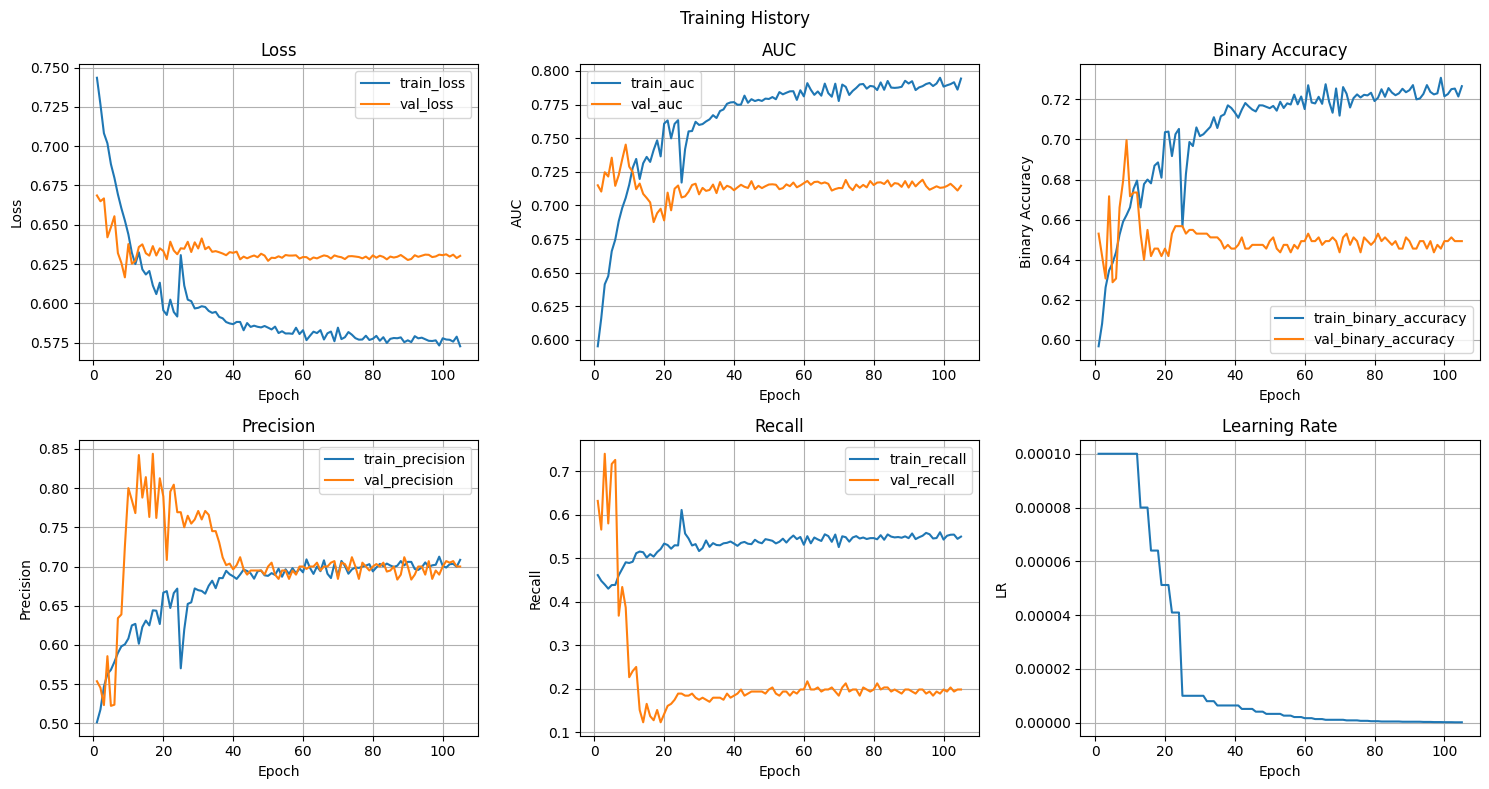

In [40]:
all_histories = append_histories(history_patient1, history_patient2, history_patient3)

plot_history(all_histories)

In [41]:
logger_path = str(dir_model_logs/model.name/f"initial_{model.name}_{backbone.name}_patient_random.csv")

pd.DataFrame(all_histories).to_csv(logger_path)

f"Saved at {logger_path}"

'Saved at ../models/logs/ensemble_resnet50v2/initial_ensemble_resnet50v2_resnet50v2_patient_random.csv'

## FINAL EVALUATION

#### Split by Image ID

In [9]:
df_train_image_random = pd.read_csv(dir_data_split / "train_image_random_aug.csv") # get the augmented version
df_val_image_random = pd.read_csv(dir_data_split / "val_image_random_aug.csv") # get the augmented version

# Combine train and val data for full training
df_full_train_image_random = pd.concat([df_train_image_random, df_val_image_random], ignore_index=True)

ds_full_train_image_random = get_dataset(
    df_full_train_image_random["augmented"].values,
    df_full_train_image_random["label"].values,
    image_resize=default_cfg["image_resize"],
    dataset_cfg=training_cfg["dataset"]["train"],
).map(lambda x, y: (grayscale_to_rgb(x), y)) # convert to 3-channel images

In [10]:
# Load the model initial weights
model.load_weights(save_path)

# Compile model with optimizer, loss, and metrics
optimizer = Adam(learning_rate=training_cfg["final_training"]["lr"])
loss = BinaryCrossentropy()
metrics = [AUC(), BinaryAccuracy(), Precision(), Recall()]

model.compile(optimizer=optimizer, loss=loss, metrics=metrics)

# Setup callbacks
early_stop = EarlyStopping(monitor="loss", **training_cfg["final_training"]["early_stopping"])
lr_reducer = ReduceLROnPlateau(monitor="loss", **training_cfg["final_training"]["reduce_on_plateau"])

In [11]:
# Train model
history_image_full = model.fit(
    ds_full_train_image_random,
    callbacks=[early_stop, lr_reducer],
    epochs=40, # when model start to overfit during experiments
)

Epoch 1/40


2025-09-22 01:57:14.918683: I tensorflow/stream_executor/cuda/cuda_dnn.cc:384] Loaded cuDNN version 8905
2025-09-22 01:57:14.989700: I tensorflow/core/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2025-09-22 01:57:14.994384: I tensorflow/core/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2025-09-22 01:57:14.994416: W tensorflow/stream_executor/gpu/asm_compiler.cc:80] Couldn't get ptxas version string: INTERNAL: Couldn't invoke ptxas --version
2025-09-22 01:57:14.998351: I tensorflow/core/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2025-09-22 01:57:14.998447: W tensorflow/stream_executor/gpu/redzone_allocator.cc:314] INTERNAL: Failed to launch ptxas
Relying on driver to perform ptx compilation. 
Modify $PATH to customize ptxas location.
This message will be only logged once.
2025-09-22 01:57:15.024673: I tensorflow/stream_executor/cuda/c

403/403 [==============================] - 21s 45ms/step - loss: 0.7466 - auc: 0.6094 - binary_accuracy: 0.5838 - precision: 0.4958 - recall: 0.5389 - lr: 1.0000e-04
Epoch 2/40
403/403 [==============================] - 16s 39ms/step - loss: 0.7255 - auc: 0.6318 - binary_accuracy: 0.6033 - precision: 0.5192 - recall: 0.5136 - lr: 1.0000e-04
Epoch 3/40
403/403 [==============================] - 16s 38ms/step - loss: 0.7090 - auc: 0.6518 - binary_accuracy: 0.6165 - precision: 0.5380 - recall: 0.4968 - lr: 1.0000e-04
Epoch 4/40
403/403 [==============================] - 16s 38ms/step - loss: 0.6996 - auc: 0.6599 - binary_accuracy: 0.6226 - precision: 0.5482 - recall: 0.4825 - lr: 1.0000e-04
Epoch 5/40
403/403 [==============================] - 16s 38ms/step - loss: 0.6889 - auc: 0.6747 - binary_accuracy: 0.6346 - precision: 0.5649 - recall: 0.4957 - lr: 1.0000e-04
Epoch 6/40
403/403 [==============================] - 16s 38ms/step - loss: 0.6781 - auc: 0.6884 - binary_accuracy: 0.6436 - p

In [12]:
# Save final model
model.save(dir_model_final/model.name/f"{model.name}_{backbone.name}_image_random.h5")

In [13]:
#Export final training history
logger_path = str(dir_model_logs/model.name/f"full_{model.name}_{backbone.name}_image_random.csv")

pd.DataFrame(history_image_full.history).to_csv(logger_path)

f"Saved at {logger_path}"

'Saved at ../models/logs/ensemble_resnet50v2/full_ensemble_resnet50v2_resnet50v2_image_random.csv'

In [14]:
# Setup testing data for evaluation
df_test_image_random = pd.read_csv(dir_data_split / "test_image_random.csv")

ds_test_image_random = prepare_dataset( # use prepare dataset, only converting path to image and get labels
    df_test_image_random["processed"].values,
    df_test_image_random["label"].values,
    image_resize=(default_cfg["image_resize"], default_cfg["image_resize"])
).map(lambda x, y: (grayscale_to_rgb(x), y)) # convert to 3-channel images

ds_test_image_random = ds_test_image_random.batch(64)

In [15]:
# Final evaluation
model.evaluate(ds_test_image_random)

11/11 [==============================] - 1s 38ms/step - loss: 0.6298 - auc: 0.6988 - binary_accuracy: 0.6719 - precision: 0.6642 - recall: 0.3297   


[0.6298133134841919,
 0.6988224387168884,
 0.671875,
 0.6642335653305054,
 0.3297101557254791]

#### Split by Patient ID

In [16]:
df_train_patient_random = pd.read_csv(dir_data_split / "train_patient_random_aug.csv") # get the augmented version
df_val_patient_random = pd.read_csv(dir_data_split / "val_patient_random_aug.csv") # get the augmented version

# Combine train and val data for full training
df_full_train_patient_random = pd.concat([df_train_patient_random, df_val_patient_random], ignore_index=True)

ds_full_train_patient_random = get_dataset(
    df_full_train_patient_random["augmented"].values,
    df_full_train_patient_random["label"].values,
    image_resize=default_cfg["image_resize"],
    dataset_cfg=training_cfg["dataset"]["train"],
).map(lambda x, y: (grayscale_to_rgb(x), y)) # convert to 3-channel images

In [17]:
# Load the model initial weights
model.load_weights(save_path)

# Compile model with optimizer, loss, and metrics
optimizer = Adam(learning_rate=training_cfg["final_training"]["lr"])
loss = BinaryCrossentropy()
metrics = [AUC(), BinaryAccuracy(), Precision(), Recall()]

model.compile(optimizer=optimizer, loss=loss, metrics=metrics)

# Setup callbacks
early_stop = EarlyStopping(monitor="loss", **training_cfg["final_training"]["early_stopping"])
lr_reducer = ReduceLROnPlateau(monitor="loss", **training_cfg["final_training"]["reduce_on_plateau"])

In [18]:
# Train model
history_patient_full = model.fit(
    ds_full_train_patient_random,
    callbacks=[early_stop, lr_reducer],
    epochs=20, # when model start to overfit during experiments
)

Epoch 1/20


2025-09-22 02:08:01.870832: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:390] Filling up shuffle buffer (this may take a while): 2885 of 5000


  3/392 [..............................] - ETA: 17s - loss: 0.8044 - auc_1: 0.0000e+00 - binary_accuracy: 0.4531 - precision_1: 0.0000e+00 - recall_1: 0.0000e+00    

2025-09-22 02:08:09.893535: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:415] Shuffle buffer filled.


392/392 [==============================] - 36s 41ms/step - loss: 0.7484 - auc_1: 0.6008 - binary_accuracy: 0.5796 - precision_1: 0.4797 - recall_1: 0.5226 - lr: 1.0000e-04
Epoch 2/20
392/392 [==============================] - 15s 39ms/step - loss: 0.7278 - auc_1: 0.6231 - binary_accuracy: 0.5962 - precision_1: 0.4985 - recall_1: 0.4924 - lr: 1.0000e-04
Epoch 3/20
392/392 [==============================] - 15s 39ms/step - loss: 0.7107 - auc_1: 0.6440 - binary_accuracy: 0.6137 - precision_1: 0.5221 - recall_1: 0.4773 - lr: 1.0000e-04
Epoch 4/20
392/392 [==============================] - 16s 41ms/step - loss: 0.7003 - auc_1: 0.6542 - binary_accuracy: 0.6201 - precision_1: 0.5320 - recall_1: 0.4696 - lr: 1.0000e-04
Epoch 5/20
392/392 [==============================] - 17s 42ms/step - loss: 0.6912 - auc_1: 0.6666 - binary_accuracy: 0.6318 - precision_1: 0.5513 - recall_1: 0.4597 - lr: 1.0000e-04
Epoch 6/20
392/392 [==============================] - 15s 39ms/step - loss: 0.6844 - auc_1: 0.67

In [19]:
# Save final model
model.save(dir_model_final/model.name/f"{model.name}_{backbone.name}_patient_random.h5")

In [20]:
#Export final training history
logger_path = str(dir_model_logs/model.name/f"full_{model.name}_{backbone.name}_patient_random.csv")

pd.DataFrame(history_patient_full.history).to_csv(logger_path)

f"Saved at {logger_path}"

'Saved at ../models/logs/ensemble_resnet50v2/full_ensemble_resnet50v2_resnet50v2_patient_random.csv'

In [21]:
# Setup testing data for evaluation
df_test_patient_random = pd.read_csv(dir_data_split / "test_patient_random.csv")

ds_test_patient_random = prepare_dataset( # use prepare dataset, only converting path to image and get labels
    df_test_patient_random["processed"].values,
    df_test_patient_random["label"].values,
    image_resize=(default_cfg["image_resize"], default_cfg["image_resize"])
).map(lambda x, y: (grayscale_to_rgb(x), y)) # convert to 3-channel images

ds_test_patient_random = ds_test_patient_random.batch(64)

In [22]:
# Final evaluation
model.evaluate(ds_test_patient_random)

13/13 [==============================] - 22s 2s/step - loss: 0.6103 - auc_1: 0.7708 - binary_accuracy: 0.6921 - precision_1: 0.8322 - recall_1: 0.3531


[0.6102986335754395,
 0.7707698345184326,
 0.6921119689941406,
 0.8321678042411804,
 0.3531157374382019]